## **Install Libraries**

In [70]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn streamlit joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Import Libraries**

In [71]:

# Data manipulation
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score #testing model multiple time

# Feature Scaling 
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation 
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, roc_auc_score,roc_curve


# saving train modell
import joblib

# Stop warningd 
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
#print("All libraries loaded")

## **Data Collection**

In [72]:
df = pd.read_csv("C:/Users/User/Downloads/Diabetes_Risk_Prediction/diabetic_data.csv")  
df.head()  

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [73]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()


Shape: (101766, 50)
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

In [74]:
# Summary statistics
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## **Data Cleaning**

In [75]:
import pandas as pd
import numpy as np

# 2. DATA CLEANING FUNCTION
def clean_data(df):
    # 2.1: Target banana - 3 classes ko 2 me convert
    # Why: 'NO', '>30', '<30' ko hum 0/1 me change karenge
    df['Diabetes_Risk'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)
    print("\nClass Distribution:\n", df['Diabetes_Risk'].value_counts(normalize=True)) 
    # Output ~70% 0, 30% 1 = slightly imbalanced ✅

    # 2.2: '?' values ko NaN me badlo
    # Why: ML model '?' ko samajh nahi sakta
    df.replace('?', np.nan, inplace=True) 
    
    # 2.3: Jo columns 90% khali hain unko drop kar do
    # Why: Inko fill karna bekar hai, data kharab ho jayega
    cols_to_drop = ['weight', 'payer_code', 'medical_specialty'] 
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    # 2.4: Categorical columns ke NaN ko 'Unknown' se fill karo
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    
    # 2.5: Number wale columns ke NaN ko median se fill karo
    # Why: Median outliers se affect nahi hota
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    
    # 2.6: Outliers ko cap karo
    # Why: 14 din hospital me rehna rare hai, model confuse ho jayega
    df['time_in_hospital'] = df['time_in_hospital'].clip(upper=10) # 10 se zyada ko 10 bana do
    df['num_lab_procedures'] = df['num_lab_procedures'].clip(upper=100) 
    
    # 2.7: Duplicate patient hatao
    df.drop_duplicates(subset=['patient_nbr'], inplace=True)
    
    print("\nCleaned Shape:", df.shape)
    return df

df_clean = clean_data(df)

# 3. CHECK: Koi NaN bacha to nahi
print("\nTotal Missing Values:", df_clean.isnull().sum().sum()) # Iska output 0 aana chahiye
df_clean.head()


Class Distribution:
 Diabetes_Risk
0    0.539119
1    0.460881
Name: proportion, dtype: float64

Cleaned Shape: (71518, 48)

Total Missing Values: 0


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Diabetes_Risk
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Up,No,No,No,No,No,Ch,Yes,>30,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## **Exploratory Data Analysis**

1.**Count Plot**

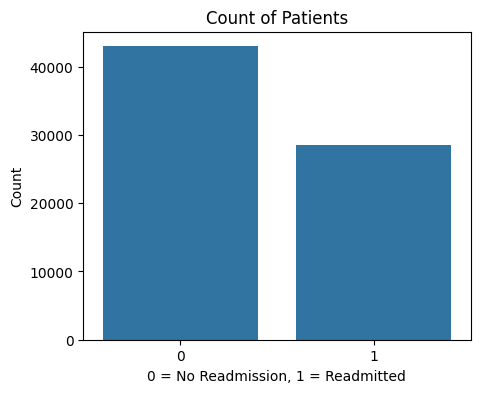

In [76]:
plt.figure(figsize=(5,4))
sns.countplot(x="Diabetes_Risk", data=df_clean)
plt.title("Count of Patients")
plt.xlabel("0 = No Readmission, 1 = Readmitted")
plt.ylabel("Count")
plt.show()


2. **Class percentage** 

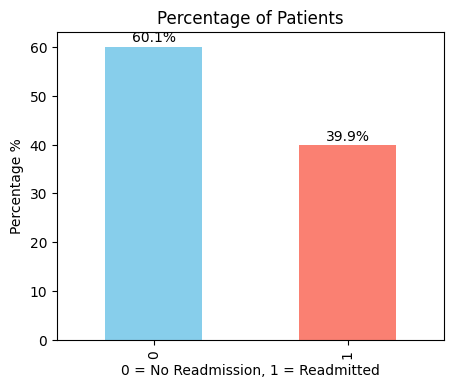

In [77]:
plt.figure(figsize=(5,4))
counts = df_clean['Diabetes_Risk'].value_counts(normalize=True) * 100
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Percentage of Patients")
plt.xlabel("0 = No Readmission, 1 = Readmitted")
plt.ylabel("Percentage %")
for i, v in enumerate(counts):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()


3. **Corelation Map**

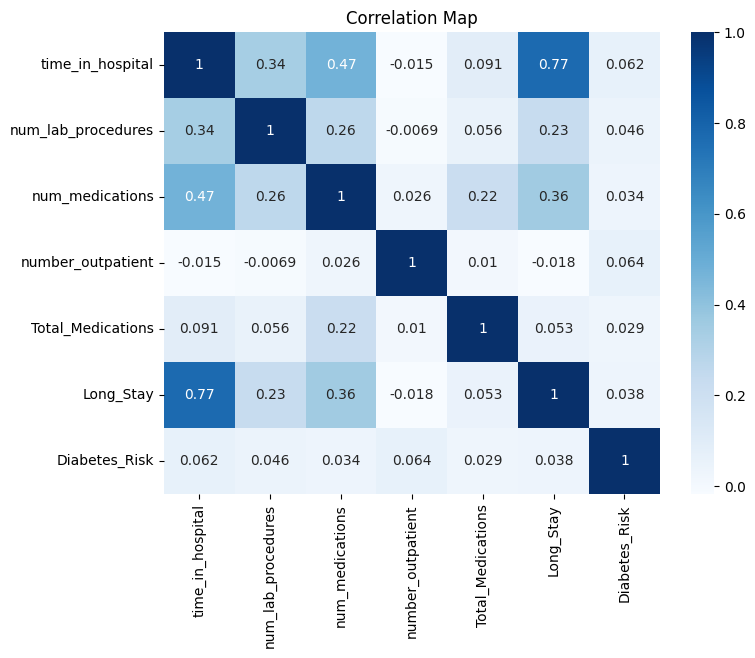

In [85]:
# Feature Engineering pehle
med_cols = ['metformin', 'insulin', 'glipizide', 'glyburide']
df_clean['Total_Medications'] = 0
for col in med_cols:
    df_clean['Total_Medications'] += (df_clean[col]!= 'No')
df_clean['Long_Stay'] = (df_clean['time_in_hospital'] > 7).astype(int)

plt.figure(figsize=(8,6))
num_data = df_clean[['time_in_hospital', 'num_lab_procedures', 'num_medications',
                     'number_outpatient', 'Total_Medications', 'Long_Stay', 'Diabetes_Risk']]
corr = num_data.corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Map")
plt.show()

In [80]:
# Missing values
df.isnull().sum()


encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

In [81]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

## **Feature Engineering + Scaling**

In [84]:
# 1. X aur y
X = df_clean.drop(['readmitted', 'Diabetes_Risk'], axis=1)
y = df_clean['Diabetes_Risk']

# 2. Categorical ko 0,1 me
X = pd.get_dummies(X, drop_first=True)

print("Features Ready ✅ Shape:", X.shape)

Features Ready ✅ Shape: (71518, 2265)


## **Train Test Split + Scaling**

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (57214, 2265)  Test shape: (14304, 2265)


## **Handle Imbalance with SMOTE**

In [87]:
print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Diabetes_Risk
0    34388
1    22826
Name: count, dtype: int64

After SMOTE:
Diabetes_Risk
1    34388
0    34388
Name: count, dtype: int64


## **3 Model Training**

In [88]:
model1 = LogisticRegression(max_iter=500)
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model3 = XGBClassifier(eval_metric='logloss', random_state=42)

print("Training Logistic...")
model1.fit(X_train_smote, y_train_smote)
print("Training RandomForest...")
model2.fit(X_train_smote, y_train_smote)
print("Training XGBoost...")
model3.fit(X_train_smote, y_train_smote)
print("All 3 Models Trained ✅")

Training Logistic...
Training RandomForest...
Training XGBoost...
All 3 Models Trained ✅


## **Hyperparameter tuning**

In [90]:
from sklearn.model_selection import GridSearchCV

models = {
    'Logistic': (LogisticRegression(max_iter=500), {'C': [0.1, 1, 10]}),
    'RandomForest': (RandomForestClassifier(random_state=42), {'n_estimators': [100], 'max_depth': [10]}),
    'XGBoost': (XGBClassifier(eval_metric='logloss', random_state=42), {'n_estimators': [100], 'max_depth': [3]})
}

best_models = {}
for name, (model, params) in models.items():
    print(f"Tuning {name}...")
    # 3 changes: cv=2, n_jobs=1, param kam kar diye
    grid = GridSearchCV(model, params, cv=2, scoring='roc_auc', n_jobs=1, verbose=1)
    grid.fit(X_train_smote, y_train_smote)
    best_models[name] = grid.best_estimator_
    print(f"Best {name}:", grid.best_params_)
print("Tuning Done ✅")

Tuning Logistic...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Logistic: {'C': 0.1}
Tuning RandomForest...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best RandomForest: {'max_depth': 10, 'n_estimators': 100}
Tuning XGBoost...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best XGBoost: {'max_depth': 3, 'n_estimators': 100}
Tuning Done ✅


## **Model Evaluation**

In [91]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


===== Logistic =====
              precision    recall  f1-score   support

           0       0.70      0.63      0.67      8597
           1       0.52      0.60      0.55      5707

    accuracy                           0.62     14304
   macro avg       0.61      0.61      0.61     14304
weighted avg       0.63      0.62      0.62     14304

ROC AUC: 0.6545040721965288

===== RandomForest =====
              precision    recall  f1-score   support

           0       0.67      0.77      0.71      8597
           1       0.54      0.42      0.47      5707

    accuracy                           0.63     14304
   macro avg       0.61      0.59      0.59     14304
weighted avg       0.62      0.63      0.62     14304

ROC AUC: 0.651757057481044

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.69      0.81      0.75      8597
           1       0.62      0.46      0.53      5707

    accuracy                           0.67     14304
   m

## **Model Comparison**

In [92]:
results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    results[name] = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC_AUC'])
results_df = results_df.sort_values(by='ROC_AUC', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]
print(f"\nBest Model is: {best_model_name} ✅")

          Model   ROC_AUC
2       XGBoost  0.709004
0      Logistic  0.654504
1  RandomForest  0.651757

Best Model is: XGBoost ✅


## **Best Model**

In [93]:
joblib.dump(best_model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print(f"{best_model_name} and Scaler Saved as.joblib ✅")

XGBoost and Scaler Saved as.joblib ✅


In [94]:
joblib.dump(X.columns.tolist(), 'columns.joblib')
print("Columns Saved ✅")

Columns Saved ✅
